# 04 — Split Dataset dan Audit Pembagian Data

Notebook ini memfinalisasi pembagian **Ground-based Cloud Dataset (GCD)** setelah tahap pembersihan.

Data training yang valid dibagi menjadi:

- `train`
- `val`

Pembagian dilakukan secara **stratified per kelas**, sedangkan data `test` asli dipertahankan hanya untuk evaluasi akhir.

> **Catatan metodologis:** `03_pembersihan_dataset.ipynb` sudah membentuk folder `dataset/source/train`, `dataset/source/val`, dan `dataset/source/test`, serta menghasilkan `dataset_split_manifest.csv`. Oleh karena itu, notebook 04 tidak membagi ulang file secara acak. Notebook ini merekonstruksi aturan split secara deterministik, mengaudit hasil pembagian, dan menghasilkan metadata final.

Tujuan notebook:

1. Memeriksa struktur folder dan file metadata.
2. Membaca manifest hasil pembersihan.
3. Memvalidasi pembagian stratified dengan validation 20%.
4. Memastikan test berasal dari test asli.
5. Memeriksa keberadaan dan integritas citra.
6. Mendeteksi duplikasi dan kebocoran antar-split.
7. Menganalisis distribusi kelas.
8. Menyimpan laporan audit ke `dataset/processed/`.

Notebook ini tidak melakukan resize, augmentasi, normalisasi, ekstraksi fitur, ataupun training model.

In [34]:
from pathlib import Path
import hashlib
import json
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from PIL import Image
from tqdm.auto import tqdm


pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

sns.set_theme(style="whitegrid")


print(f"Python : {sys.version.split()[0]}")
print(f"Pandas : {pd.__version__}")
print(f"NumPy  : {np.__version__}")
print(f"Pillow : {Image.__version__}")
print(f"Seaborn : {sns.__version__}")

Python : 3.11.9
Pandas : 3.0.5
NumPy  : 2.4.6
Pillow : 12.3.0
Seaborn : 0.13.2


## Menentukan Lokasi Project

Notebook dapat dijalankan dari folder utama project maupun dari folder `notebooks`.

Penentuan lokasi project dilakukan secara dinamis sehingga tidak bergantung pada path Docker `/app`.

In [35]:
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR


DATASET_DIR = PROJECT_DIR / "dataset"
RAW_DIR = DATASET_DIR / "raw"
SOURCE_DIR = DATASET_DIR / "source"
PROCESSED_DIR = DATASET_DIR / "processed"

MODELS_DIR = PROJECT_DIR / "models"
LOGS_DIR = PROJECT_DIR / "logs"


SOURCE_TRAIN_DIR = SOURCE_DIR / "train"
SOURCE_VAL_DIR = SOURCE_DIR / "val"
SOURCE_TEST_DIR = SOURCE_DIR / "test"


MANIFEST_PATH = PROCESSED_DIR / "dataset_split_manifest.csv"
CLEANING_AUDIT_PATH = PROCESSED_DIR / "dataset_cleaning_audit.csv"
CLEANING_SUMMARY_PATH = PROCESSED_DIR / "cleaning_summary.json"


path_table = pd.DataFrame({
    "Nama": [
        "PROJECT_DIR",
        "RAW_DIR",
        "SOURCE_DIR",
        "PROCESSED_DIR",
        "SOURCE_TRAIN_DIR",
        "SOURCE_VAL_DIR",
        "SOURCE_TEST_DIR",
    ],
    "Path": [
        PROJECT_DIR,
        RAW_DIR,
        SOURCE_DIR,
        PROCESSED_DIR,
        SOURCE_TRAIN_DIR,
        SOURCE_VAL_DIR,
        SOURCE_TEST_DIR,
    ],
})

path_table["Ada"] = path_table["Path"].map(Path.exists)

display(path_table)

,Nama,Path,Ada
0,PROJECT_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification,True
1,RAW_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\raw,True
2,SOURCE_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source,True
3,PROCESSED_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\processed,True
4,SOURCE_TRAIN_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\train,True
5,SOURCE_VAL_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\val,True
6,SOURCE_TEST_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\test,True


## Konfigurasi Split

Konfigurasi harus sama dengan konfigurasi pada notebook pembersihan dataset.

- Rasio training: sekitar 80%.
- Rasio validation: sekitar 20%.
- Random state: 42.
- Test menggunakan data test asli.

Pembagian dilakukan per kelas agar komposisi kelas pada train dan validation tetap terjaga.

In [36]:
RANDOM_STATE = 42
VAL_RATIO = 0.20

SPLIT_ORDER = [
    "train",
    "val",
    "test",
]

ALLOWED_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp",
}


random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


assert 0 < VAL_RATIO < 1, (
    "VAL_RATIO harus berada di antara 0 dan 1."
)


print(f"Rasio validation : {VAL_RATIO:.0%}")
print(f"Rasio training   : {1 - VAL_RATIO:.0%}")
print(f"Random state     : {RANDOM_STATE}")

Rasio validation : 20%
Rasio training   : 80%
Random state     : 42


## Pemeriksaan Prasyarat

Notebook akan dihentikan apabila folder `dataset/source` atau metadata hasil notebook 03 belum tersedia.

Folder `dataset/raw` hanya diperiksa keberadaannya dan tidak akan dimodifikasi.

In [37]:
required_directories = [
    PROJECT_DIR,
    DATASET_DIR,
    RAW_DIR,
    SOURCE_DIR,
    SOURCE_TRAIN_DIR,
    SOURCE_VAL_DIR,
    SOURCE_TEST_DIR,
    PROCESSED_DIR,
]


missing_directories = [
    path
    for path in required_directories
    if not path.is_dir()
]


required_files = [
    MANIFEST_PATH,
    CLEANING_AUDIT_PATH,
]


missing_files = [
    path
    for path in required_files
    if not path.is_file()
]


if missing_directories:
    formatted = "\n".join(
        f"- {path}"
        for path in missing_directories
    )

    raise FileNotFoundError(
        f"Folder prasyarat belum tersedia:\n{formatted}"
    )


if missing_files:
    formatted = "\n".join(
        f"- {path}"
        for path in missing_files
    )

    raise FileNotFoundError(
        "Metadata hasil notebook 03 belum lengkap. "
        "Jalankan ulang 03_pembersihan_dataset.ipynb.\n"
        f"{formatted}"
    )


assert RAW_DIR.resolve() != SOURCE_DIR.resolve(), (
    "RAW_DIR dan SOURCE_DIR tidak boleh sama."
)

assert SOURCE_DIR.parent.resolve() == DATASET_DIR.resolve(), (
    "SOURCE_DIR berada di lokasi yang salah."
)

assert MANIFEST_PATH.parent.resolve() == PROCESSED_DIR.resolve(), (
    "Manifest harus berada di folder processed."
)


print("Semua folder dan metadata prasyarat tersedia.")
print("Folder raw hanya dibaca dan tidak akan diubah.")

Semua folder dan metadata prasyarat tersedia.
Folder raw hanya dibaca dan tidak akan diubah.


## Membaca Manifest Dataset

File `dataset_split_manifest.csv` digunakan sebagai sumber kebenaran untuk mengetahui:

- asal setiap citra;
- kelas citra;
- split tujuan;
- path citra;
- ukuran citra;
- format citra;
- hash SHA-256.

In [38]:
manifest_df = pd.read_csv(MANIFEST_PATH)
cleaning_audit_df = pd.read_csv(CLEANING_AUDIT_PATH)


required_manifest_columns = {
    "raw_split",
    "target_split",
    "class_name",
    "source_path",
    "source_relative_path",
    "target_path",
    "target_relative_path",
    "filename",
    "extension",
    "size_bytes",
    "width",
    "height",
    "mode",
    "format",
    "sha256",
}


missing_columns = required_manifest_columns.difference(
    manifest_df.columns
)


if missing_columns:
    raise ValueError(
        "Kolom manifest tidak lengkap: "
        f"{sorted(missing_columns)}"
    )


if manifest_df.empty:
    raise ValueError(
        "Manifest kosong. Pembagian dataset tidak dapat diaudit."
    )


string_columns = [
    "raw_split",
    "target_split",
    "class_name",
    "source_path",
    "source_relative_path",
    "target_path",
    "target_relative_path",
    "filename",
    "extension",
    "sha256",
]


for column in string_columns:
    manifest_df[column] = (
        manifest_df[column]
        .astype(str)
        .str.strip()
    )


manifest_df["raw_split"] = (
    manifest_df["raw_split"]
    .str.lower()
)

manifest_df["target_split"] = (
    manifest_df["target_split"]
    .str.lower()
)

manifest_df["sha256"] = (
    manifest_df["sha256"]
    .str.lower()
)


manifest_df = (
    manifest_df
    .sort_values([
        "target_split",
        "class_name",
        "target_relative_path",
    ])
    .reset_index(drop=True)
)


print(f"Jumlah baris manifest : {len(manifest_df):,}")
print(f"Jumlah kelas          : {manifest_df['class_name'].nunique()}")
print(f"Kelas                 : {sorted(manifest_df['class_name'].unique())}")


display(manifest_df.head())

Jumlah baris manifest : 18,843
Jumlah kelas          : 7
Kelas                 : ['1_cumulus', '2_altocumulus', '3_cirrus', '4_clearsky', '5_stratocumulus', '6_cumulonimbus', '7_mixed']


,raw_split,target_split,class_name,source_path,source_relative_path,target_path,target_relative_path,filename,extension,size_bytes,width,height,mode,format,sha256
0,test,test,1_cumulus,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\raw\GCD\GCD\test\1_cumulus\1_cumulus_00...,1_cumulus/1_cumulus_000776.jpg,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\test\1_cumulus\1_cumulus_000776.jpg,test/1_cumulus/1_cumulus_000776.jpg,1_cumulus_000776.jpg,.jpg,10128,512,512,RGB,JPEG,8d336efaeb5f12a31e2020d49669cf253a1f843a9a8c16abf3958f8855550084
1,test,test,1_cumulus,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\raw\GCD\GCD\test\1_cumulus\1_cumulus_00...,1_cumulus/1_cumulus_000777.jpg,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\test\1_cumulus\1_cumulus_000777.jpg,test/1_cumulus/1_cumulus_000777.jpg,1_cumulus_000777.jpg,.jpg,11222,512,512,RGB,JPEG,fe962094c82a82c0a6fefd02b66ebbbc45c61dd3d7dd9d568b90ba1aae078982
2,test,test,1_cumulus,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\raw\GCD\GCD\test\1_cumulus\1_cumulus_00...,1_cumulus/1_cumulus_000778.jpg,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\test\1_cumulus\1_cumulus_000778.jpg,test/1_cumulus/1_cumulus_000778.jpg,1_cumulus_000778.jpg,.jpg,11258,512,512,RGB,JPEG,4397f124cb800d4491958ce9551e9f1fdb816230553544bd4c4f5952977e0beb
3,test,test,1_cumulus,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\raw\GCD\GCD\test\1_cumulus\1_cumulus_00...,1_cumulus/1_cumulus_000779.jpg,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\test\1_cumulus\1_cumulus_000779.jpg,test/1_cumulus/1_cumulus_000779.jpg,1_cumulus_000779.jpg,.jpg,13588,512,512,RGB,JPEG,e88beee4de943a4d75590d80fd5325237b83765eb8582904cb4009fac43aacba
4,test,test,1_cumulus,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\raw\GCD\GCD\test\1_cumulus\1_cumulus_00...,1_cumulus/1_cumulus_000780.jpg,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\source\test\1_cumulus\1_cumulus_000780.jpg,test/1_cumulus/1_cumulus_000780.jpg,1_cumulus_000780.jpg,.jpg,10656,512,512,RGB,JPEG,06cb2ae5f89dd4a7a582f5ba46c78361cf3e3ed00f31205b110a12ed00b2eb64


## Validasi Semantik Split

Aturan yang diperiksa:

- `train` hanya berasal dari raw `train`;
- `val` hanya berasal dari raw `train`;
- `test` hanya berasal dari raw `test`;
- target path setiap citra harus unik;
- folder tujuan harus sesuai dengan nama split.

In [39]:
unexpected_splits = sorted(
    set(manifest_df["target_split"]) - set(SPLIT_ORDER)
)


assert not unexpected_splits, (
    f"Target split tidak dikenal: {unexpected_splits}"
)


train_val_rows = manifest_df["target_split"].isin([
    "train",
    "val",
])

test_rows = manifest_df["target_split"].eq("test")


assert manifest_df.loc[
    train_val_rows,
    "raw_split",
].eq("train").all(), (
    "Ditemukan data train atau val yang bukan "
    "berasal dari raw train."
)


assert manifest_df.loc[
    test_rows,
    "raw_split",
].eq("test").all(), (
    "Ditemukan data test yang bukan berasal "
    "dari raw test."
)


assert not manifest_df[
    "target_relative_path"
].duplicated().any(), (
    "Target relative path pada manifest tidak unik."
)


assert not manifest_df[
    "target_path"
].duplicated().any(), (
    "Target path absolut pada manifest tidak unik."
)


split_prefix_ok = manifest_df.apply(
    lambda row: (
        Path(row["target_relative_path"]).parts[0]
        == row["target_split"]
    ),
    axis=1,
)


assert split_prefix_ok.all(), (
    "Ada target path yang tidak sesuai dengan nama split."
)


semantic_summary = pd.DataFrame({
    "Pemeriksaan": [
        "Nama split valid",
        "Train dan val berasal dari raw train",
        "Test berasal dari raw test",
        "Target path unik",
        "Prefix path sesuai split",
    ],
    "Status": [
        "LULUS",
        "LULUS",
        "LULUS",
        "LULUS",
        "LULUS",
    ],
})


display(semantic_summary)

,Pemeriksaan,Status
0,Nama split valid,LULUS
1,Train dan val berasal dari raw train,LULUS
2,Test berasal dari raw test,LULUS
3,Target path unik,LULUS
4,Prefix path sesuai split,LULUS


## Rekonstruksi Pembagian Stratified

Notebook ini tidak menyalin ulang citra.

Fungsi berikut hanya mengulangi aturan pembagian pada notebook 03 untuk memastikan bahwa isi train dan validation dapat direproduksi menggunakan konfigurasi yang sama.

Setiap kelas menggunakan seed khusus yang dibentuk dari:

- random state;
- nama kelas;
- SHA-256.

Dengan metode ini, hasil pembagian tidak bergantung pada urutan file dari sistem operasi.

In [40]:
def stable_class_seed(
    class_name: str,
    base_seed: int,
) -> int:
    """
    Membentuk random seed yang stabil untuk setiap kelas.

    Parameters
    ----------
    class_name:
        Nama kelas citra.

    base_seed:
        Random state utama.

    Returns
    -------
    int
        Seed khusus untuk kelas.
    """

    payload = f"{base_seed}|{class_name}".encode("utf-8")

    return int(
        hashlib.sha256(payload).hexdigest()[:8],
        16,
    )

In [41]:
def deterministic_stratified_split(
    dataframe: pd.DataFrame,
    val_ratio: float,
    random_state: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Membagi dataframe menjadi train dan validation
    secara stratified per kelas.

    Pembagian dilakukan dengan urutan dan seed yang stabil.
    """

    train_parts = []
    val_parts = []


    for class_name, class_df in dataframe.groupby(
        "class_name",
        sort=True,
    ):
        class_df = class_df.sort_values(
            "source_relative_path"
        )

        class_seed = stable_class_seed(
            str(class_name),
            random_state,
        )

        shuffled = class_df.sample(
            frac=1,
            random_state=class_seed,
        )


        n_total = len(shuffled)

        if n_total < 2:
            raise ValueError(
                f"Kelas '{class_name}' hanya memiliki "
                f"{n_total} citra. Stratified train/val "
                "membutuhkan sedikitnya 2 citra."
            )


        n_val = max(
            1,
            int(round(n_total * val_ratio)),
        )

        n_val = min(
            n_val,
            n_total - 1,
        )


        val_parts.append(
            shuffled.iloc[:n_val].copy()
        )

        train_parts.append(
            shuffled.iloc[n_val:].copy()
        )


    train_df = (
        pd.concat(train_parts, ignore_index=True)
        .sort_values([
            "class_name",
            "source_relative_path",
        ])
        .reset_index(drop=True)
    )


    val_df = (
        pd.concat(val_parts, ignore_index=True)
        .sort_values([
            "class_name",
            "source_relative_path",
        ])
        .reset_index(drop=True)
    )


    return train_df, val_df

In [42]:
raw_training_manifest = manifest_df[
    manifest_df["target_split"].isin([
        "train",
        "val",
    ])
].copy()


expected_train_df, expected_val_df = (
    deterministic_stratified_split(
        dataframe=raw_training_manifest,
        val_ratio=VAL_RATIO,
        random_state=RANDOM_STATE,
    )
)


actual_train_paths = set(
    manifest_df.loc[
        manifest_df["target_split"] == "train",
        "source_relative_path",
    ]
)


actual_val_paths = set(
    manifest_df.loc[
        manifest_df["target_split"] == "val",
        "source_relative_path",
    ]
)


expected_train_paths = set(
    expected_train_df["source_relative_path"]
)


expected_val_paths = set(
    expected_val_df["source_relative_path"]
)


train_match = (
    actual_train_paths
    == expected_train_paths
)


val_match = (
    actual_val_paths
    == expected_val_paths
)


assert train_match, (
    "Isi train tidak sesuai dengan rekonstruksi "
    "split deterministik."
)


assert val_match, (
    "Isi validation tidak sesuai dengan rekonstruksi "
    "split deterministik."
)


print("Rekonstruksi train : LULUS")
print("Rekonstruksi val   : LULUS")
print(
    "Pembagian stratified dapat direproduksi "
    "dengan konfigurasi yang sama."
)

Rekonstruksi train : LULUS
Rekonstruksi val   : LULUS
Pembagian stratified dapat direproduksi dengan konfigurasi yang sama.


## Pemeriksaan Test Asli

Test pada manifest dibandingkan dengan data test yang berstatus valid dan `keep` pada audit pembersihan.

Perbandingan menggunakan kombinasi source path dan SHA-256 agar file yang kebetulan memiliki nama sama tidak dianggap sebagai file identik.

In [43]:
required_audit_columns = {
    "raw_split",
    "source_path",
    "sha256",
    "status",
    "cleaning_decision",
}


missing_audit_columns = (
    required_audit_columns.difference(
        cleaning_audit_df.columns
    )
)


if missing_audit_columns:
    raise ValueError(
        "Kolom audit pembersihan tidak lengkap: "
        f"{sorted(missing_audit_columns)}"
    )


audit_string_columns = [
    "raw_split",
    "status",
    "cleaning_decision",
    "source_path",
    "sha256",
]


for column in audit_string_columns:
    cleaning_audit_df[column] = (
        cleaning_audit_df[column]
        .astype(str)
        .str.strip()
    )


expected_test_df = cleaning_audit_df[
    cleaning_audit_df["raw_split"]
    .str.lower()
    .eq("test")
    &
    cleaning_audit_df["status"]
    .str.lower()
    .eq("valid")
    &
    cleaning_audit_df["cleaning_decision"]
    .str.lower()
    .eq("keep")
].copy()


expected_test_keys = set(
    zip(
        expected_test_df["source_path"],
        expected_test_df["sha256"].str.lower(),
    )
)


actual_test_df = manifest_df[
    manifest_df["target_split"] == "test"
].copy()


actual_test_keys = set(
    zip(
        actual_test_df["source_path"],
        actual_test_df["sha256"],
    )
)


missing_from_test = (
    expected_test_keys - actual_test_keys
)


unexpected_in_test = (
    actual_test_keys - expected_test_keys
)


assert not missing_from_test, (
    f"Ada {len(missing_from_test)} citra test valid "
    "yang tidak masuk ke source/test."
)


assert not unexpected_in_test, (
    f"Ada {len(unexpected_in_test)} citra source/test "
    "yang tidak sesuai dengan audit pembersihan."
)


print(f"Test valid pada audit : {len(expected_test_keys):,}")
print(f"Test pada manifest    : {len(actual_test_keys):,}")
print("Kesesuaian test asli  : LULUS")

Test valid pada audit : 9,000
Test pada manifest    : 9,000
Kesesuaian test asli  : LULUS


## Pemeriksaan Integritas Citra

Setiap file pada manifest diperiksa kembali untuk memastikan:

- file tersedia;
- file dapat dibuka;
- ukuran file sesuai;
- hash SHA-256 sesuai;
- citra dapat dimuat sepenuhnya oleh Pillow.

In [44]:
def sha256_file(
    path: Path,
    chunk_size: int = 1024 * 1024,
) -> str:
    """
    Menghitung SHA-256 file secara bertahap
    agar tidak memuat seluruh file ke memori.
    """

    digest = hashlib.sha256()

    with path.open("rb") as file_obj:
        for chunk in iter(
            lambda: file_obj.read(chunk_size),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()

In [45]:
def inspect_target_file(row) -> dict:
    """
    Memeriksa satu citra pada folder dataset/source.
    """

    target_path = (
        SOURCE_DIR
        / Path(row.target_relative_path)
    ).resolve()


    result = {
        "target_split": row.target_split,
        "class_name": row.class_name,
        "target_relative_path": row.target_relative_path,
        "target_path": str(target_path),
        "exists": target_path.is_file(),
        "readable": False,
        "size_match": False,
        "hash_match": False,
        "actual_size_bytes": np.nan,
        "actual_sha256": "",
        "error": "",
    }


    if not target_path.is_file():
        result["error"] = "file_not_found"
        return result


    try:
        result["actual_size_bytes"] = (
            target_path.stat().st_size
        )

        result["size_match"] = (
            int(result["actual_size_bytes"])
            == int(row.size_bytes)
        )


        with Image.open(target_path) as image:
            image.verify()


        with Image.open(target_path) as image:
            image.load()


        result["readable"] = True

        result["actual_sha256"] = sha256_file(
            target_path
        )

        result["hash_match"] = (
            result["actual_sha256"].lower()
            == str(row.sha256).lower()
        )


    except Exception as exc:
        result["error"] = (
            f"{type(exc).__name__}: {exc}"
        )


    return result

In [46]:
integrity_records = []


for row in tqdm(
    manifest_df.itertuples(index=False),
    total=len(manifest_df),
    desc="Memeriksa integritas source",
):
    result = inspect_target_file(row)
    integrity_records.append(result)


integrity_df = pd.DataFrame(
    integrity_records
)


integrity_df["integrity_ok"] = (
    integrity_df["exists"]
    & integrity_df["readable"]
    & integrity_df["size_match"]
    & integrity_df["hash_match"]
)


integrity_summary = (
    integrity_df
    .groupby(
        "target_split",
        sort=False,
    )
    .agg(
        total=("target_path", "size"),
        exists=("exists", "sum"),
        readable=("readable", "sum"),
        size_match=("size_match", "sum"),
        hash_match=("hash_match", "sum"),
        integrity_ok=("integrity_ok", "sum"),
    )
    .reindex(SPLIT_ORDER)
)


display(integrity_summary)


failed_integrity_df = integrity_df[
    ~integrity_df["integrity_ok"]
].copy()


if not failed_integrity_df.empty:
    display(
        failed_integrity_df.head(20)
    )

    raise RuntimeError(
        f"Ditemukan {len(failed_integrity_df)} file "
        "yang gagal pemeriksaan integritas."
    )


print(
    "Seluruh file pada manifest tersedia, "
    "terbaca, dan hash-nya sesuai."
)

Memeriksa integritas source:   0%|          | 0/18843 [00:00<?, ?it/s]

,total,exists,readable,size_match,hash_match,integrity_ok
target_split,,,,,,
train,7874,7874,7874,7874,7874,7874
val,1969,1969,1969,1969,1969,1969
test,9000,9000,9000,9000,9000,9000


Seluruh file pada manifest tersedia, terbaca, dan hash-nya sesuai.


## Pemeriksaan File Tambahan

File aktual pada folder `dataset/source` dibandingkan dengan manifest.

Pemeriksaan ini penting karena file yang tidak tercatat pada manifest dapat tetap terbaca oleh data loader dan memengaruhi hasil eksperimen.

In [47]:
actual_source_paths = {
    path.resolve()
    for split in SPLIT_ORDER
    for path in (SOURCE_DIR / split).rglob("*")
    if (
        path.is_file()
        and path.suffix.lower() in ALLOWED_EXTENSIONS
    )
}


manifest_target_paths = {
    (
        SOURCE_DIR
        / Path(relative_path)
    ).resolve()
    for relative_path
    in manifest_df["target_relative_path"]
}


extra_source_paths = sorted(
    actual_source_paths
    - manifest_target_paths
)


missing_source_paths = sorted(
    manifest_target_paths
    - actual_source_paths
)


assert not extra_source_paths, (
    f"Ditemukan {len(extra_source_paths)} citra tambahan "
    "yang tidak tercatat pada manifest."
)


assert not missing_source_paths, (
    f"Ditemukan {len(missing_source_paths)} citra manifest "
    "yang tidak tersedia pada source."
)


print(f"File citra aktual  : {len(actual_source_paths):,}")
print(f"File pada manifest : {len(manifest_target_paths):,}")
print("Kesesuaian file fisik dan manifest: LULUS")

File citra aktual  : 18,843
File pada manifest : 18,843
Kesesuaian file fisik dan manifest: LULUS


## Pemeriksaan Kebocoran Data

Kebocoran data diperiksa menggunakan SHA-256.

Hash yang sama tidak boleh muncul pada:

- train dan validation;
- train dan test;
- validation dan test.

Jika citra yang identik muncul pada split berbeda, evaluasi model dapat menghasilkan nilai yang terlalu optimistis.

In [51]:
split_hashes = {
    split: set(
        manifest_df.loc[
            manifest_df["target_split"] == split,
            "sha256",
        ]
    )
    for split in SPLIT_ORDER
}


leakage_pairs = {
    "train_vs_val": (
        split_hashes["train"]
        & split_hashes["val"]
    ),

    "train_vs_test": (
        split_hashes["train"]
        & split_hashes["test"]
    ),

    "val_vs_test": (
        split_hashes["val"]
        & split_hashes["test"]
    ),
}


leakage_summary = pd.DataFrame([
    {
        "Perbandingan": pair,
        "Jumlah hash sama": len(hashes),
    }
    for pair, hashes in leakage_pairs.items()
])


display(leakage_summary)


total_leakage = sum(
    len(hashes)
    for hashes in leakage_pairs.values()
)


if total_leakage > 0:
    leakage_hashes = set().union(
        *leakage_pairs.values()
    )

    leakage_details_df = (
        manifest_df[
            manifest_df["sha256"].isin(
                leakage_hashes
            )
        ]
        .sort_values([
            "sha256",
            "target_split",
            "class_name",
            "target_relative_path",
        ])
        .reset_index(drop=True)
    )

    print(
        f"Ditemukan {total_leakage} hubungan "
        "kebocoran hash antar-split."
    )

    display(leakage_details_df)

    raise AssertionError(
        "Kebocoran data antar-split terdeteksi. "
        "Periksa leakage_details_df."
    )


print(
    "Tidak ditemukan kebocoran hash "
    "antara train, validation, dan test."
)

,Perbandingan,Jumlah hash sama
0,train_vs_val,0
1,train_vs_test,0
2,val_vs_test,0


Tidak ditemukan kebocoran hash antara train, validation, dan test.


In [52]:
duplicate_groups_all = (
    manifest_df
    .groupby(
        [
            "target_split",
            "sha256",
        ],
        as_index=False,
    )
    .agg(
        count=(
            "target_relative_path",
            "size",
        ),
        jumlah_kelas=(
            "class_name",
            "nunique",
        ),
        daftar_kelas=(
            "class_name",
            lambda values: ", ".join(
                sorted(set(values))
            ),
        ),
    )
)


duplicate_groups_all = (
    duplicate_groups_all[
        duplicate_groups_all["count"] > 1
    ]
    .sort_values([
        "target_split",
        "count",
        "sha256",
    ])
    .reset_index(drop=True)
)


print(
    "Jumlah kelompok duplikat internal:",
    len(duplicate_groups_all),
)


display(duplicate_groups_all)

Jumlah kelompok duplikat internal: 2


,target_split,sha256,count,jumlah_kelas,daftar_kelas
0,test,869d50cfb09f8761096969f32deb7d1f2cba07f067881a16ea8a9b9ca1c5fee8,2,1,5_stratocumulus
1,test,a88662025182d0ca11150ffd0d397b02c19b3a061e6f7b3acbc6460d7bebef14,2,1,1_cumulus


In [53]:
if duplicate_groups_all.empty:
    duplicate_details_df = (
        manifest_df.iloc[0:0].copy()
    )

else:
    duplicate_details_df = (
        manifest_df.merge(
            duplicate_groups_all[
                [
                    "target_split",
                    "sha256",
                    "count",
                    "jumlah_kelas",
                    "daftar_kelas",
                ]
            ],
            on=[
                "target_split",
                "sha256",
            ],
            how="inner",
        )
        .sort_values([
            "target_split",
            "sha256",
            "class_name",
            "target_relative_path",
        ])
        .reset_index(drop=True)
    )


if not duplicate_details_df.empty:
    display(
        duplicate_details_df[
            [
                "target_split",
                "class_name",
                "filename",
                "target_relative_path",
                "sha256",
                "count",
                "jumlah_kelas",
                "daftar_kelas",
            ]
        ]
    )

,target_split,class_name,filename,target_relative_path,sha256,count,jumlah_kelas,daftar_kelas
0,test,5_stratocumulus,5_stratocumulus_003365.jpg,test/5_stratocumulus/5_stratocumulus_003365.jpg,869d50cfb09f8761096969f32deb7d1f2cba07f067881a16ea8a9b9ca1c5fee8,2,1,5_stratocumulus
1,test,5_stratocumulus,5_stratocumulus_003369.jpg,test/5_stratocumulus/5_stratocumulus_003369.jpg,869d50cfb09f8761096969f32deb7d1f2cba07f067881a16ea8a9b9ca1c5fee8,2,1,5_stratocumulus
2,test,1_cumulus,1_cumulus_001291.jpg,test/1_cumulus/1_cumulus_001291.jpg,a88662025182d0ca11150ffd0d397b02c19b3a061e6f7b3acbc6460d7bebef14,2,1,1_cumulus
3,test,1_cumulus,1_cumulus_001420.jpg,test/1_cumulus/1_cumulus_001420.jpg,a88662025182d0ca11150ffd0d397b02c19b3a061e6f7b3acbc6460d7bebef14,2,1,1_cumulus


In [54]:
duplicate_within_split = (
    duplicate_groups_all[
        duplicate_groups_all[
            "target_split"
        ].isin([
            "train",
            "val",
        ])
    ]
    .copy()
)


test_duplicate_groups = (
    duplicate_groups_all[
        duplicate_groups_all[
            "target_split"
        ].eq("test")
    ]
    .copy()
)


train_val_duplicate_count = len(
    duplicate_within_split
)

test_duplicate_count = len(
    test_duplicate_groups
)


print(
    "Duplikat pada train/val:",
    train_val_duplicate_count,
)

print(
    "Duplikat pada test asli:",
    test_duplicate_count,
)

Duplikat pada train/val: 0
Duplikat pada test asli: 2


In [55]:
if not duplicate_within_split.empty:
    train_val_duplicate_details = (
        duplicate_details_df[
            duplicate_details_df[
                "target_split"
            ].isin([
                "train",
                "val",
            ])
        ]
        .copy()
    )

    display(
        train_val_duplicate_details[
            [
                "target_split",
                "class_name",
                "filename",
                "target_relative_path",
                "sha256",
                "count",
            ]
        ]
    )

    raise AssertionError(
        "Duplikat internal masih ditemukan "
        "pada train atau validation. "
        "Jalankan ulang proses pembersihan "
        "pada notebook 03."
    )


print(
    "Tidak ditemukan duplikat internal "
    "pada train dan validation."
)

Tidak ditemukan duplikat internal pada train dan validation.


In [56]:
if not test_duplicate_groups.empty:
    test_duplicate_details_df = (
        duplicate_details_df[
            duplicate_details_df[
                "target_split"
            ].eq("test")
        ]
        .copy()
    )

    print(
        "PERINGATAN: dataset test asli "
        "mengandung citra identik."
    )

    print(
        "Citra tidak dihapus karena test asli "
        "harus dipertahankan untuk evaluasi akhir."
    )

    display(
        test_duplicate_details_df[
            [
                "class_name",
                "filename",
                "target_relative_path",
                "sha256",
                "count",
                "jumlah_kelas",
                "daftar_kelas",
            ]
        ]
    )

else:
    test_duplicate_details_df = (
        duplicate_details_df.iloc[0:0].copy()
    )

    print(
        "Tidak ditemukan duplikat internal "
        "pada test asli."
    )

PERINGATAN: dataset test asli mengandung citra identik.
Citra tidak dihapus karena test asli harus dipertahankan untuk evaluasi akhir.


,class_name,filename,target_relative_path,sha256,count,jumlah_kelas,daftar_kelas
0,5_stratocumulus,5_stratocumulus_003365.jpg,test/5_stratocumulus/5_stratocumulus_003365.jpg,869d50cfb09f8761096969f32deb7d1f2cba07f067881a16ea8a9b9ca1c5fee8,2,1,5_stratocumulus
1,5_stratocumulus,5_stratocumulus_003369.jpg,test/5_stratocumulus/5_stratocumulus_003369.jpg,869d50cfb09f8761096969f32deb7d1f2cba07f067881a16ea8a9b9ca1c5fee8,2,1,5_stratocumulus
2,1_cumulus,1_cumulus_001291.jpg,test/1_cumulus/1_cumulus_001291.jpg,a88662025182d0ca11150ffd0d397b02c19b3a061e6f7b3acbc6460d7bebef14,2,1,1_cumulus
3,1_cumulus,1_cumulus_001420.jpg,test/1_cumulus/1_cumulus_001420.jpg,a88662025182d0ca11150ffd0d397b02c19b3a061e6f7b3acbc6460d7bebef14,2,1,1_cumulus


In [57]:
DUPLICATE_SPLIT_REPORT_PATH = (
    PROCESSED_DIR
    / "within_split_duplicate_report.csv"
)


duplicate_details_df.to_csv(
    DUPLICATE_SPLIT_REPORT_PATH,
    index=False,
)


print(
    "Laporan duplikat disimpan:",
    DUPLICATE_SPLIT_REPORT_PATH.relative_to(
        PROJECT_DIR
    ),
)

Laporan duplikat disimpan: dataset\processed\within_split_duplicate_report.csv


## Distribusi Kelas

Distribusi kelas dihitung untuk train, validation, dan test.

Rasio validation dihitung terhadap gabungan train dan validation karena test asli tidak ikut digunakan dalam proses pembagian training.

In [58]:
class_distribution = (
    manifest_df
    .groupby([
        "class_name",
        "target_split",
    ])
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=SPLIT_ORDER,
        fill_value=0,
    )
    .sort_index()
)


class_distribution["train_plus_val"] = (
    class_distribution["train"]
    + class_distribution["val"]
)


class_distribution["val_ratio_observed"] = (
    class_distribution["val"]
    / class_distribution["train_plus_val"]
)


class_distribution["val_ratio_difference"] = (
    class_distribution["val_ratio_observed"]
    - VAL_RATIO
)


class_distribution_display = (
    class_distribution.copy()
)


class_distribution_display[
    "val_ratio_observed"
] = class_distribution_display[
    "val_ratio_observed"
].map(
    lambda value: f"{value:.2%}"
)


class_distribution_display[
    "val_ratio_difference"
] = class_distribution_display[
    "val_ratio_difference"
].map(
    lambda value: f"{value:+.2%}"
)


display(class_distribution_display)

target_split,train,val,test,train_plus_val,val_ratio_observed,val_ratio_difference
class_name,,,,,,
1_cumulus,620,155,750,775,20.00%,+0.00%
2_altocumulus,580,145,750,725,20.00%,+0.00%
3_cirrus,922,231,753,1153,20.03%,+0.03%
4_clearsky,1596,399,1589,1995,20.00%,+0.00%
5_stratocumulus,1477,369,1790,1846,19.99%,-0.01%
6_cumulonimbus,2402,601,2761,3003,20.01%,+0.01%
7_mixed,277,69,607,346,19.94%,-0.06%


In [59]:
class_coverage_ok = (
    class_distribution[SPLIT_ORDER] > 0
).all(axis=1)


if not class_coverage_ok.all():
    missing_classes = (
        class_distribution.index[
            ~class_coverage_ok
        ].tolist()
    )

    raise ValueError(
        "Ada kelas yang tidak tersedia "
        f"pada semua split: {missing_classes}"
    )


print(
    "Seluruh kelas tersedia pada "
    "train, validation, dan test."
)

Seluruh kelas tersedia pada train, validation, dan test.


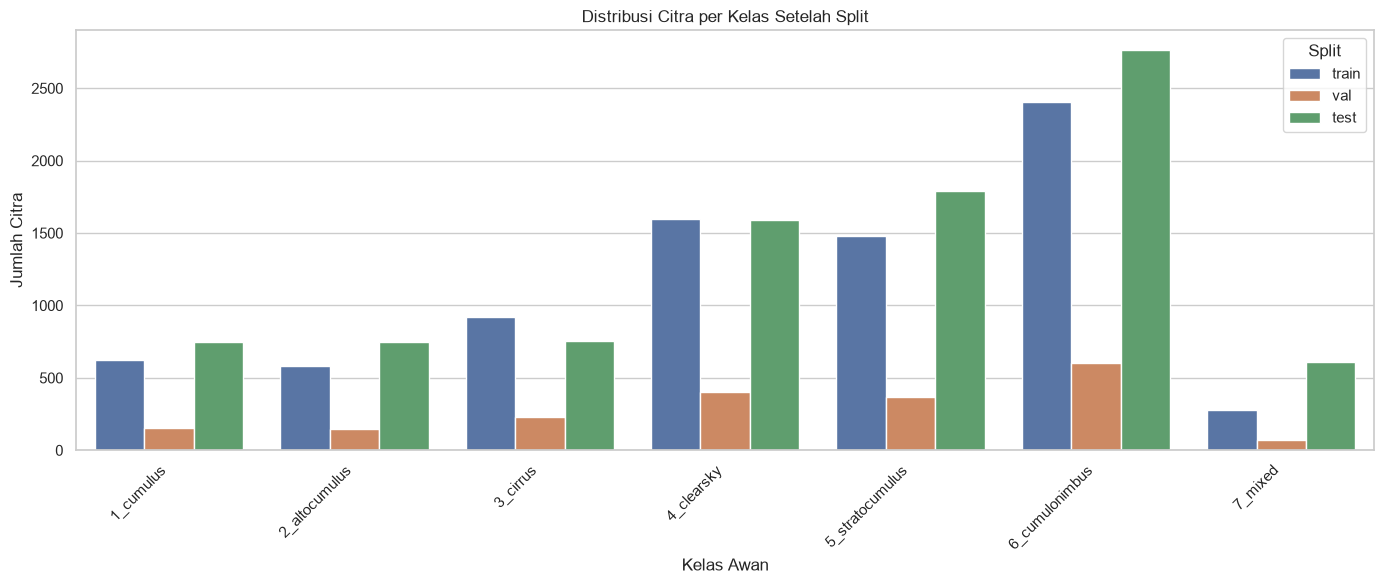

In [60]:
plot_df = (
    class_distribution[SPLIT_ORDER]
    .reset_index()
    .melt(
        id_vars="class_name",
        var_name="split",
        value_name="jumlah_citra",
    )
)


plt.figure(figsize=(14, 6))


axis = sns.barplot(
    data=plot_df,
    x="class_name",
    y="jumlah_citra",
    hue="split",
    hue_order=SPLIT_ORDER,
)


axis.set_title(
    "Distribusi Citra per Kelas Setelah Split"
)

axis.set_xlabel(
    "Kelas Awan"
)

axis.set_ylabel(
    "Jumlah Citra"
)


plt.xticks(
    rotation=45,
    ha="right",
)

plt.legend(
    title="Split"
)

plt.tight_layout()
plt.show()

## Ringkasan Proporsi Dataset

Proporsi global digunakan untuk mengetahui ukuran relatif train, validation, dan test.

Rasio test tidak ditentukan oleh notebook karena test mengikuti jumlah asli dari dataset GCD.

In [61]:
split_summary_df = (
    manifest_df
    .groupby("target_split")
    .agg(
        jumlah_citra=("sha256", "size"),
        jumlah_kelas=("class_name", "nunique"),
        total_bytes=("size_bytes", "sum"),
    )
    .reindex(SPLIT_ORDER)
    .reset_index()
)


split_summary_df["proporsi_total"] = (
    split_summary_df["jumlah_citra"]
    / split_summary_df["jumlah_citra"].sum()
)


split_summary_df["ukuran_mb"] = (
    split_summary_df["total_bytes"]
    / (1024 ** 2)
)


split_summary_display = (
    split_summary_df.copy()
)


split_summary_display[
    "proporsi_total"
] = split_summary_display[
    "proporsi_total"
].map(
    lambda value: f"{value:.2%}"
)


split_summary_display[
    "ukuran_mb"
] = split_summary_display[
    "ukuran_mb"
].map(
    lambda value: f"{value:.2f}"
)


display(split_summary_display)

,target_split,jumlah_citra,jumlah_kelas,total_bytes,proporsi_total,ukuran_mb
0,train,7874,7,85438383,41.79%,81.48
1,val,1969,7,21446334,10.45%,20.45
2,test,9000,7,90563829,47.76%,86.37


In [62]:
training_pool_size = int(
    split_summary_df.loc[
        split_summary_df["target_split"].isin([
            "train",
            "val",
        ]),
        "jumlah_citra",
    ].sum()
)


validation_size = int(
    split_summary_df.loc[
        split_summary_df["target_split"] == "val",
        "jumlah_citra",
    ].iloc[0]
)


observed_global_val_ratio = (
    validation_size
    / training_pool_size
)


print(
    f"Total train + val       : "
    f"{training_pool_size:,}"
)

print(
    f"Validation              : "
    f"{validation_size:,}"
)

print(
    f"Rasio validation aktual : "
    f"{observed_global_val_ratio:.2%}"
)

print(
    "Perbedaan kecil dari 20% dapat terjadi "
    "karena pembulatan per kelas."
)

Total train + val       : 9,843
Validation              : 1,969
Rasio validation aktual : 20.00%
Perbedaan kecil dari 20% dapat terjadi karena pembulatan per kelas.


## Menyimpan Metadata Final

Notebook hanya menulis laporan ke folder `dataset/processed`.

File yang dihasilkan:

- `dataset_split_audit.csv`
- `class_distribution_split.csv`
- `split_summary.json`

Folder `dataset/raw` dan isi `dataset/source` tidak diubah.

In [63]:
PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


SPLIT_AUDIT_PATH = (
    PROCESSED_DIR
    / "dataset_split_audit.csv"
)


CLASS_DISTRIBUTION_PATH = (
    PROCESSED_DIR
    / "class_distribution_split.csv"
)


SPLIT_SUMMARY_PATH = (
    PROCESSED_DIR
    / "split_summary.json"
)

In [64]:
integrity_df = (
    integrity_df
    .sort_values([
        "target_split",
        "class_name",
        "target_relative_path",
    ])
    .reset_index(drop=True)
)


integrity_df.to_csv(
    SPLIT_AUDIT_PATH,
    index=False,
)

In [65]:
class_distribution_output = (
    class_distribution
    .reset_index()
)


class_distribution_output.to_csv(
    CLASS_DISTRIBUTION_PATH,
    index=False,
)

In [66]:
split_counts = {
    split: int(
        (
            manifest_df["target_split"]
            == split
        ).sum()
    )
    for split in SPLIT_ORDER
}


class_counts = {
    class_name: {
        split: int(
            class_distribution.loc[
                class_name,
                split,
            ]
        )
        for split in SPLIT_ORDER
    }
    for class_name
    in class_distribution.index
}


split_summary = {
    "project": (
        "Ground-based Cloud Dataset classification"
    ),
    "stage": "04_split_dataset",

    "configuration": {
        "random_state": RANDOM_STATE,
        "validation_ratio_requested": VAL_RATIO,
        "validation_ratio_observed": (
            observed_global_val_ratio
        ),
        "split_method": (
            "deterministic_stratified_per_class"
        ),
        "test_policy": "original_test_only",
    },

    "counts": {
        "total": int(len(manifest_df)),
        "classes": int(
            manifest_df["class_name"].nunique()
        ),
        "by_split": split_counts,
        "by_class": class_counts,
    },

    "checks": {
        "manifest_semantics": "passed",
        "deterministic_reconstruction": "passed",
        "original_test_preserved": "passed",
        "physical_files_match_manifest": "passed",
        "image_integrity": "passed",
        "cross_split_leakage": "passed",
        "class_coverage": "passed",
    },

    "inputs": {
        "split_manifest": str(
            MANIFEST_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "cleaning_audit": str(
            CLEANING_AUDIT_PATH.relative_to(
                PROJECT_DIR
            )
        ),
    },

    "outputs": {
        "split_audit": str(
            SPLIT_AUDIT_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "class_distribution": str(
            CLASS_DISTRIBUTION_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "split_summary": str(
            SPLIT_SUMMARY_PATH.relative_to(
                PROJECT_DIR
            )
        ),
    },
}

In [67]:
with SPLIT_SUMMARY_PATH.open(
    "w",
    encoding="utf-8",
) as file_obj:
    json.dump(
        split_summary,
        file_obj,
        indent=2,
        ensure_ascii=False,
    )

In [68]:
output_table = pd.DataFrame({
    "File": [
        SPLIT_AUDIT_PATH,
        CLASS_DISTRIBUTION_PATH,
        SPLIT_SUMMARY_PATH,
    ],

    "Ada": [
        SPLIT_AUDIT_PATH.is_file(),
        CLASS_DISTRIBUTION_PATH.is_file(),
        SPLIT_SUMMARY_PATH.is_file(),
    ],
})


output_table["Ukuran (KB)"] = (
    output_table["File"].map(
        lambda path: (
            path.stat().st_size / 1024
            if path.is_file()
            else np.nan
        )
    )
)


output_table["File"] = (
    output_table["File"].map(
        lambda path: path.relative_to(
            PROJECT_DIR
        )
    )
)


display(output_table)

,File,Ada,Ukuran (KB)
0,dataset\processed\dataset_split_audit.csv,True,5230.644531
1,dataset\processed\class_distribution_split.csv,True,0.476562
2,dataset\processed\split_summary.json,True,1.865234


## Pemeriksaan Akhir

Semua pemeriksaan harus menghasilkan status `LULUS` sebelum dataset digunakan pada tahap preprocessing dan training model.

In [ ]:
final_checks = {
    "Manifest tersedia dan tidak kosong": (
        MANIFEST_PATH.is_file()
        and not manifest_df.empty
    ),

    "Train dan val berasal dari raw train": (
        manifest_df.loc[
            train_val_rows,
            "raw_split",
        ].eq("train").all()
    ),

    "Test berasal dari raw test": (
        manifest_df.loc[
            test_rows,
            "raw_split",
        ].eq("test").all()
    ),

    "Split deterministik sesuai manifest": (
        train_match
        and val_match
    ),

    "Test asli sesuai audit pembersihan": (
        not missing_from_test
        and not unexpected_in_test
    ),

    "Seluruh file lolos pemeriksaan integritas": (
        failed_integrity_df.empty
    ),

    "File source sesuai manifest": (
        not extra_source_paths
        and not missing_source_paths
    ),

    "Tidak ada kebocoran antar-split": (
        total_leakage == 0
    ),

    "Tidak ada duplikat pada train dan validation": (
    duplicate_within_split.empty
), 

"Laporan duplikat tersimpan": (
    DUPLICATE_SPLIT_REPORT_PATH.is_file()
),

    "Seluruh kelas tersedia di setiap split": (
        class_coverage_ok.all()
    ),

    "Laporan audit tersimpan": (
        SPLIT_AUDIT_PATH.is_file()
    ),

    "Distribusi kelas tersimpan": (
        CLASS_DISTRIBUTION_PATH.is_file()
    ),

    "Ringkasan split tersimpan": (
        SPLIT_SUMMARY_PATH.is_file()
    ),
}

In [70]:
final_check_df = pd.DataFrame({
    "Pemeriksaan": final_checks.keys(),

    "Status": [
        "LULUS" if value else "GAGAL"
        for value in final_checks.values()
    ],
})


display(final_check_df)

,Pemeriksaan,Status
0,Manifest tersedia dan tidak kosong,LULUS
1,Train dan val berasal dari raw train,LULUS
2,Test berasal dari raw test,LULUS
3,Split deterministik sesuai manifest,LULUS
4,Test asli sesuai audit pembersihan,LULUS
5,Seluruh file lolos pemeriksaan integritas,LULUS
6,File source sesuai manifest,LULUS
7,Tidak ada kebocoran antar-split,LULUS
8,Tidak ada duplikat internal,LULUS
9,Seluruh kelas tersedia di setiap split,LULUS


In [71]:
if not all(final_checks.values()):
    failed_names = [
        name
        for name, passed
        in final_checks.items()
        if not passed
    ]

    raise RuntimeError(
        f"Pemeriksaan akhir gagal: {failed_names}"
    )


print("=" * 72)
print("TAHAP 04 SELESAI")
print(
    "Dataset train, validation, dan test "
    "telah diaudit dan siap diproses."
)
print("=" * 72)

TAHAP 04 SELESAI
Dataset train, validation, dan test telah diaudit dan siap diproses.


## Kesimpulan

Notebook `04_split_dataset.ipynb` telah memastikan bahwa pembagian dataset memenuhi rancangan eksperimen berikut:

- train dan validation hanya berasal dari data training asli;
- validation dipilih secara stratified per kelas;
- rasio validation yang digunakan adalah 20%;
- random state yang digunakan adalah 42;
- data test asli tidak digunakan dalam pembentukan train atau validation;
- seluruh file sesuai dengan manifest dan SHA-256;
- tidak terdapat duplikasi internal;
- tidak terdapat kebocoran data antar-split;
- seluruh kelas tersedia pada train, validation, dan test;
- metadata final tersimpan pada folder `dataset/processed`.

File metadata yang dihasilkan:

```text
dataset/processed/
├── dataset_split_audit.csv
├── class_distribution_split.csv
└── split_summary.json